<a href="https://colab.research.google.com/github/sunil965/masai-aiml/blob/master/M5C1_Bias_Variance_Tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linl to PDF notes :
https://coding-platform.s3.amazonaws.com/dev/lms/tickets/3f9a9ee7-aedc-46dd-8a51-22f0250d7c72/DfmfKSRXOhstcGr0.html

# The Bias-Variance Trade-off
### Hands-on Notebook

**Learning Objectives**
1. Explain the **bias-variance trade-off** and its effect on model performance
2. Diagnose **underfitting and overfitting** using training vs. validation error

---
An ice cream shop wants to predict daily sales from temperature. We'll fit models of increasing complexity to the same 60 days of data, and watch training error and validation error move in opposite directions.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(17)


## 1. The dataset

Sales rise with temperature but taper off on the hottest days (people stay indoors) — a gentle curve, not a straight line, plus realistic day-to-day noise.


In [ ]:
n = 60
temperature = np.random.uniform(10, 40, n)  # Celsius
true_sales = 5 + 4.5*(temperature - 10) - 0.09*(temperature - 10)**2
sales = np.clip(true_sales + np.random.normal(0, 8, n), 0, None)

X = temperature.reshape(-1, 1)
y = sales
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"train: {len(X_train)} days   test: {len(X_test)} days")


train: 42 days   test: 18 days


## 2. One reusable function: fit, score, and plot a given complexity

`degree=1` is a straight line. Higher degrees let the curve bend more. We write this once and reuse it for every complexity we try.


In [ ]:
def fit_and_evaluate(degree, X_train, y_train, X_test, y_test, plot=True):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)

    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse = mean_squared_error(y_test, model.predict(X_test))

    if plot:
        xs = np.linspace(10, 40, 200).reshape(-1, 1)
        fig, ax = plt.subplots(figsize=(5.5, 4))
        ax.scatter(X_train, y_train, color="#F3F7FB", edgecolor="#122238", s=40, label="Training days")
        ax.plot(xs, model.predict(xs), color="#F2A93B", linewidth=2)
        ax.set_xlabel("Temperature (°C)"); ax.set_ylabel("Sales")
        ax.set_title(f"Degree {degree}  |  train MSE={train_mse:.1f}  test MSE={test_mse:.1f}")
        ax.legend()
        plt.tight_layout(); plt.show()

    return {"degree": degree, "train_mse": train_mse, "test_mse": test_mse}


## 3. The three models from the slides


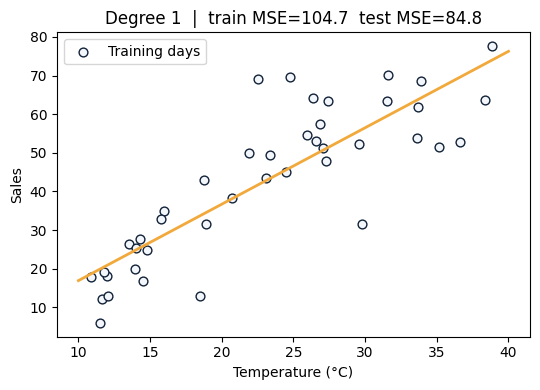

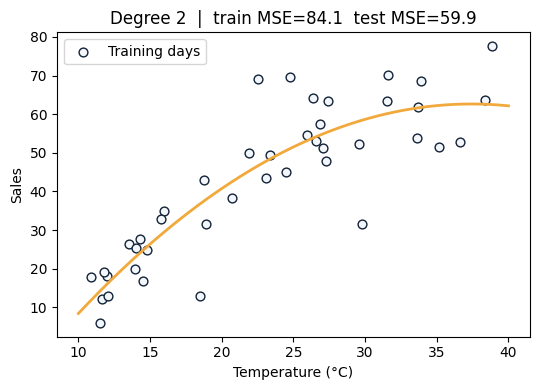

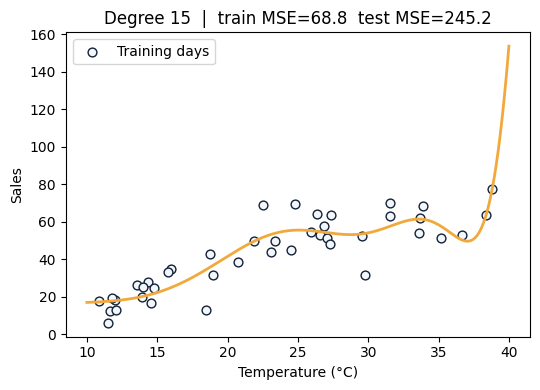

,degree,train_mse,test_mse
0,1,104.7,84.8
1,2,84.1,59.9
2,15,68.8,245.2


In [ ]:
results = [fit_and_evaluate(d, X_train, y_train, X_test, y_test) for d in [1, 2, 15]]
pd.DataFrame(results).round(1)


**Checkpoint:** this should match the slide — degree 1: train≈104.7, test≈84.8 (high bias); degree 2: train≈84.1, test≈59.9 (best balance); degree 15: train≈68.8, test≈245.2 (high variance — lowest training error, by far the worst test error).


## 4. The full trade-off curve

Let's sweep degrees 1 through 12 and plot training error against validation error — this is the classic bias-variance picture, built directly from real numbers instead of an illustration.


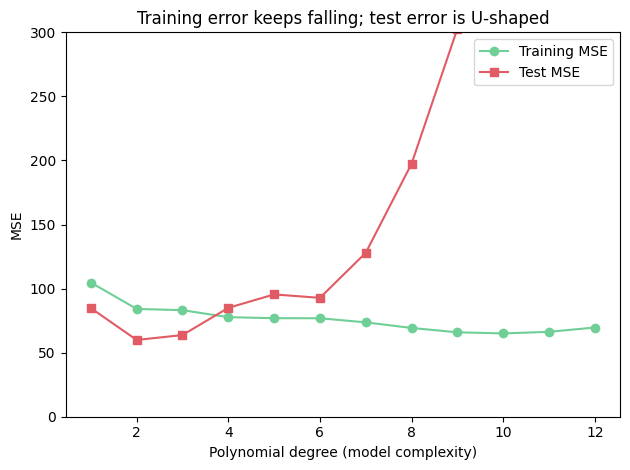

Lowest test MSE at degree 2: 59.9


In [ ]:
sweep = pd.DataFrame([fit_and_evaluate(d, X_train, y_train, X_test, y_test, plot=False) for d in range(1, 13)])

fig, ax = plt.subplots()
ax.plot(sweep["degree"], sweep["train_mse"], marker="o", color="#6FCF97", label="Training MSE")
ax.plot(sweep["degree"], sweep["test_mse"], marker="s", color="#E15B64", label="Test MSE")
ax.set_xlabel("Polynomial degree (model complexity)")
ax.set_ylabel("MSE")
ax.set_ylim(0, 300)  # cap the y-axis; test MSE explodes well past this at high degrees
ax.set_title("Training error keeps falling; test error is U-shaped")
ax.legend()
plt.tight_layout(); plt.show()

best_row = sweep.loc[sweep["test_mse"].idxmin()]
print(f"Lowest test MSE at degree {int(best_row['degree'])}: {best_row['test_mse']:.1f}")


## 5. Diagnosing from the train/test gap

The gap between training and test MSE is the practical signal, independent of the raw numbers' scale.


In [ ]:
sweep["gap"] = sweep["test_mse"] - sweep["train_mse"]
sweep.round(1)


,degree,train_mse,test_mse,gap
0,1,104.7,84.8,-20.0
1,2,84.1,59.9,-24.2
2,3,83.2,63.7,-19.4
3,4,77.7,85.0,7.3
4,5,76.9,95.5,18.6
5,6,76.8,92.8,15.9
6,7,73.6,127.9,54.3
7,8,69.3,197.4,128.1
8,9,65.9,302.8,236.9
9,10,65.0,415.6,350.6


Notice the gap is small (sometimes even negative) for low-degree models, and grows sharply for high-degree ones — a large, positive, growing gap is exactly the overfitting signature described on the slides.


## 6. Exercises


**Exercise 1.** Call `fit_and_evaluate(5, X_train, y_train, X_test, y_test)` and note whether degree 5 looks closer to the degree-2 model or the degree-15 model in terms of its train/test gap.


In [ ]:
# TODO



<details><summary>Solution</summary>

```python
fit_and_evaluate(5, X_train, y_train, X_test, y_test)
```
Degree 5 sits in between — its gap is noticeably larger than degree 2's, but nowhere near degree 15's. This is the trade-off curve in miniature: complexity creeping up starts costing you before it becomes dramatic.
</details>


**Exercise 2.** Using `sweep`, write one line to find which degree has the smallest gap between train and test MSE. Is it the same degree that had the lowest test MSE in Section 4?


In [ ]:
# TODO



<details><summary>Solution</summary>

```python
print(sweep.loc[sweep["gap"].idxmin(), "degree"])
print(sweep.loc[sweep["test_mse"].idxmin(), "degree"])
```
In this run, both happen to be degree 2 — but that's not guaranteed in general. A model can have a tiny (or even negative) gap while still being a poor fit on both training and test data — that's high bias, not a good outcome, and gap size alone wouldn't catch it. The gap tells you *which failure mode* you're in; test MSE alone tells you *how good* the model actually is. In practice you check both, and here they agree.
</details>


**Exercise 3.** A colleague only checks training error and picks the degree with the lowest one. Using `sweep`, show what degree they'd pick, and what its actual test MSE turns out to be.


In [ ]:
# TODO



<details><summary>Solution</summary>

```python
by_train = sweep.loc[sweep["train_mse"].idxmin()]
print(by_train)
```
Picking by training error alone selects degree 10 here — one of the most complex, most overfit models in the sweep (note training error isn't perfectly monotonic at very high degrees, due to numerical instability in fitting high-degree polynomial features). Its test MSE (≈415.6) is dramatically worse than degree 2's (≈59.9), which is exactly the high-variance trap this session warns about: training error alone would never reveal this.
</details>


## 7. Recap

- **Bias** is systematic error from a model too simple for the pattern — both training and test error stay high and close together (underfitting).
- **Variance** is sensitivity to the specific training data — training error keeps dropping while test error rises, opening a growing gap (overfitting).
- Plotting training vs. validation error against model complexity produces the classic trade-off curve: training error falls monotonically, validation error is U-shaped, and the minimum of that U is the model complexity worth choosing.
- **Never pick a model using training error alone** — it will always favor the most complex, most overfit option.
